In [1]:
# Celda 1 — Setup
import os
import json
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

# Asegurar que el directorio raíz del proyecto esté en el path
import sys
from pathlib import Path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation.evaluator import RAGEvaluator
from src.evaluation.eval_dataset import EVAL_DATASET

print(f"Dataset: {len(EVAL_DATASET)} preguntas")
print(f"OpenAI API key configurada: {'✅' if os.getenv('OPENAI_API_KEY') else '❌'}")
print(f"ROOT: {ROOT}")
print(f"data/raw existe: {(ROOT / 'data' / 'raw').exists()}")

Dataset: 15 preguntas
OpenAI API key configurada: ✅
ROOT: /Users/laasanchezgi/Documents/projects/datalabs/bc/mlai/bancolombia-rag
data/raw existe: True


In [2]:
# Celda 2 — Evaluación SIN reranking
evaluator = RAGEvaluator(
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    data_raw_path=str(ROOT / "data" / "raw"),
)

print("Evaluando SIN reranking...")
results_no_rerank = evaluator.evaluate_dataset(
    EVAL_DATASET,
    use_reranking=False,
    verbose=True
)
summary_no_rerank = evaluator.compute_summary(results_no_rerank)
print(json.dumps(summary_no_rerank, indent=2, ensure_ascii=False))

Evaluando SIN reranking...
{
  "avg_faithfulness": 0.8666666666666667,
  "avg_factuality_precision": 0.9653846153846154,
  "avg_factuality_recall": 0.8461538461538461,
  "avg_factuality_f1": 0.8883629191321499,
  "std_faithfulness": 0.3518657752744984,
  "std_f1": 0.17515096454773635,
  "best_question": "¿Qué es la Cuenta AFC y cuáles son sus beneficios tributarios?",
  "worst_question": "¿Qué es la tarjeta débito con funcionalidad de transporte?",
  "high_faith_low_fact": [],
  "low_faith_high_fact": [],
  "total_evaluated": 15,
  "gt_available": 13
}


In [3]:
# Celda 3 — Evaluación CON reranking
print("Evaluando CON reranking...")
results_rerank = evaluator.evaluate_dataset(
    EVAL_DATASET,
    use_reranking=True,
    verbose=True
)
summary_rerank = evaluator.compute_summary(results_rerank)
print(json.dumps(summary_rerank, indent=2, ensure_ascii=False))

Evaluando CON reranking...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{
  "avg_faithfulness": 0.8666666666666667,
  "avg_factuality_precision": 0.9653846153846154,
  "avg_factuality_recall": 0.8846153846153846,
  "avg_factuality_f1": 0.9140039447731756,
  "std_faithfulness": 0.3518657752744984,
  "std_f1": 0.16403783240065786,
  "best_question": "¿Qué es la Cuenta AFC y cuáles son sus beneficios tributarios?",
  "worst_question": "¿Qué es la tarjeta débito con funcionalidad de transporte?",
  "high_faith_low_fact": [],
  "low_faith_high_fact": [],
  "total_evaluated": 15,
  "gt_available": 13
}


In [4]:
# Celda 4 — Tabla comparativa completa
rows = []
for r_no, r_yes in zip(results_no_rerank, results_rerank):
    rows.append({
        "Pregunta": r_no["question"][:50] + "...",
        "F1 sin RR": round(r_no["factuality_f1"] or 0, 3),
        "F1 con RR": round(r_yes["factuality_f1"] or 0, 3),
        "Faith sin RR": round(r_no["faithfulness"], 3),
        "Faith con RR": round(r_yes["faithfulness"], 3),
        "Prec sin RR": round(r_no["factuality_precision"] or 0, 3),
        "Prec con RR": round(r_yes["factuality_precision"] or 0, 3),
        "Delta F1": round(
            (r_yes["factuality_f1"] or 0) - (r_no["factuality_f1"] or 0), 3
        ),
    })

df = pd.DataFrame(rows)
display(df.style.background_gradient(subset=["Delta F1"], cmap="RdYlGn"))

,Pregunta,F1 sin RR,F1 con RR,Faith sin RR,Faith con RR,Prec sin RR,Prec con RR,Delta F1
0,¿Qué es la Cuenta AFC y cuáles son sus beneficios ...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
1,¿Cuáles son las características de la Cuenta Corri...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
2,¿Qué es la cuenta Banconautas y para quién está di...,0.667000,1.000000,1.000000,1.000000,1.000000,1.000000,0.333000
3,¿Qué beneficios tiene la Cuenta Nómina de Bancolom...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,¿Cuáles son los beneficios exclusivos de la tarjet...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
5,¿Qué ofrece la tarjeta Mastercard Platinum de Banc...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
6,¿Qué es la tarjeta Mastercard Joven y cuáles son s...,0.667000,0.667000,1.000000,1.000000,1.000000,1.000000,0.000000
7,¿Qué beneficios tiene la tarjeta LifeMiles Visa de...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
8,¿Cuáles son los beneficios de la tarjeta débito Bl...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
9,¿Qué es la tarjeta débito con funcionalidad de tra...,0.600000,0.600000,1.000000,1.000000,0.750000,0.750000,0.000000


/var/folders/xp/t6sq60kn6xb52fxndvyg162h0000gn/T/ipykernel_33598/1908407756.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xp/t6sq60kn6xb52fxndvyg162h0000gn/T/ipykernel_33598/1908407756.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(ROOT / "data" / "eval_f1_vs_faithfulness.png", dpi=150, bbox_inches="tight")
/Users/laasanchezgi/Documents/projects/datalabs/bc/mlai/bancolombia-rag/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


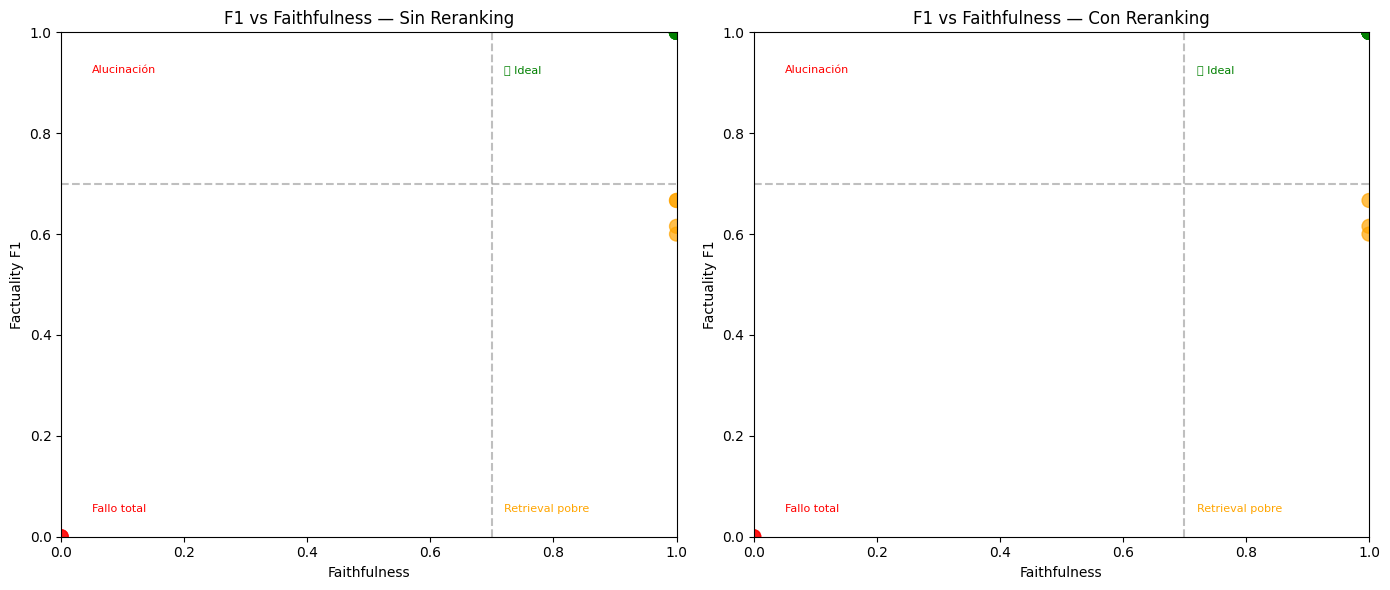

Guardado: /Users/laasanchezgi/Documents/projects/datalabs/bc/mlai/bancolombia-rag/data/eval_f1_vs_faithfulness.png


In [5]:
# Celda 5 — Gráfica 1: F1 vs Faithfulness (scatter con cuadrantes de diagnóstico)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (results, title) in zip(axes, [
    (results_no_rerank, "Sin Reranking"),
    (results_rerank, "Con Reranking")
]):
    f1s = [r["factuality_f1"] or 0 for r in results]
    faiths = [r["faithfulness"] for r in results]
    colors = ["red" if f < 0.5 else "orange" if f < 0.7 else "green" for f in f1s]

    ax.scatter(faiths, f1s, c=colors, s=100, alpha=0.7)

    # Líneas de cuadrantes
    ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(x=0.7, color="gray", linestyle="--", alpha=0.5)

    # Labels de cuadrantes
    ax.text(0.05, 0.92, "Alucinación", fontsize=8, color="red", transform=ax.transAxes)
    ax.text(0.72, 0.92, "✅ Ideal", fontsize=8, color="green", transform=ax.transAxes)
    ax.text(0.05, 0.05, "Fallo total", fontsize=8, color="red", transform=ax.transAxes)
    ax.text(0.72, 0.05, "Retrieval pobre", fontsize=8, color="orange", transform=ax.transAxes)

    ax.set_xlabel("Faithfulness")
    ax.set_ylabel("Factuality F1")
    ax.set_title(f"F1 vs Faithfulness — {title}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(ROOT / "data" / "eval_f1_vs_faithfulness.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {ROOT / 'data' / 'eval_f1_vs_faithfulness.png'}")

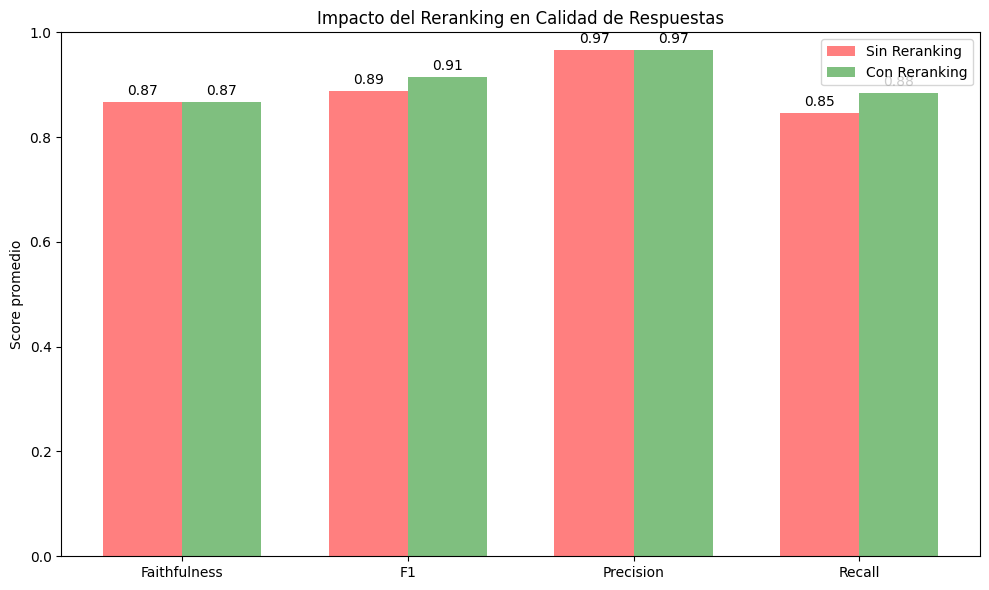

Guardado: /Users/laasanchezgi/Documents/projects/datalabs/bc/mlai/bancolombia-rag/data/eval_reranking_impact.png


In [6]:
# Celda 6 — Gráfica 2: Comparación con/sin reranking (barplot)
metrics_keys = ["avg_faithfulness", "avg_factuality_f1", "avg_factuality_precision", "avg_factuality_recall"]
labels = ["Faithfulness", "F1", "Precision", "Recall"]

x = range(len(metrics_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(
    [i - width / 2 for i in x],
    [summary_no_rerank[m] for m in metrics_keys],
    width, label="Sin Reranking", color="#ff7f7f"
)
bars2 = ax.bar(
    [i + width / 2 for i in x],
    [summary_rerank[m] for m in metrics_keys],
    width, label="Con Reranking", color="#7fbf7f"
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score promedio")
ax.set_title("Impacto del Reranking en Calidad de Respuestas")
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=3)
ax.bar_label(bars2, fmt="%.2f", padding=3)

plt.tight_layout()
plt.savefig(ROOT / "data" / "eval_reranking_impact.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {ROOT / 'data' / 'eval_reranking_impact.png'}")

In [7]:
# Celda 7 — Guardar resultados para la página Streamlit
eval_results = {
    "without_reranking": {
        "results": results_no_rerank,
        "summary": summary_no_rerank
    },
    "with_reranking": {
        "results": results_rerank,
        "summary": summary_rerank
    },
    "generated_at": datetime.now().isoformat()
}

output_path = ROOT / "data" / "eval_results.json"
output_path.parent.mkdir(parents=True, exist_ok=True)
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(eval_results, f, indent=2, ensure_ascii=False)

print(f"✅ Resultados guardados en {output_path}")
print(f"   Sin reranking — F1: {summary_no_rerank['avg_factuality_f1']:.3f} | Faith: {summary_no_rerank['avg_faithfulness']:.3f}")
print(f"   Con reranking — F1: {summary_rerank['avg_factuality_f1']:.3f} | Faith: {summary_rerank['avg_faithfulness']:.3f}")

✅ Resultados guardados en /Users/laasanchezgi/Documents/projects/datalabs/bc/mlai/bancolombia-rag/data/eval_results.json
   Sin reranking — F1: 0.888 | Faith: 0.867
   Con reranking — F1: 0.914 | Faith: 0.867
